# lab 6

In [60]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from numpy.linalg import inv

A = [
  [39, 2, -4, 8, -4],
  [-10, 48, 0, -6, 7],
  [-9, 9, 45, -6, 3],
  [-10, 8, 0, 31, -5],
  [-6, 9, -3, -2, 48]
]

b = [41, 39, 42, 24, 46]
exact = [1, 1, 1, 1, 1]

print(A)
print(b)
print(exact)



[[39, 2, -4, 8, -4], [-10, 48, 0, -6, 7], [-9, 9, 45, -6, 3], [-10, 8, 0, 31, -5], [-6, 9, -3, -2, 48]]
[41, 39, 42, 24, 46]
[1, 1, 1, 1, 1]


In [62]:
def proizsvv(v1, v2):
    return sum(v1[i] * v2[i] for i in range(len(v1)))

def mv(A, v):
    n = len(A)
    result = [0.0] * n
    for i in range(n):
        for j in range(n):
            result[i] += A[i][j] * v[j]
    return result

def razn(v1, v2):
    return [v1[i] - v2[i] for i in range(len(v1))]

def summ(v1, v2):
    return [v1[i] + v2[i] for i in range(len(v1))]

def normv(v):
    return sum(x*x for x in v) ** 0.5

def scalyar(s, v):
    return [s * x for x in v]

def mm(A, B):
    m = len(A)
    n = len(A[0])
    n2 = len(B)
    m2 = len(B[0])

    result = [[0] * n2 for _ in range(m)]

    for i in range(m):
        for j in range(n2):
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]
    return result

In [63]:
def minn(A, b, maxi=1000, epsilon=1e-12):
    n = len(b) 
    x = [0.0] * n
    t = []

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)

        if nevyazka < epsilon:
            break

        Ar = mv(A, r)
        chis = proizsvv(r, Ar)
        znam = proizsvv(Ar, Ar)

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x = summ(x, scalyar(tau, r))

        print(f"{k+1}\t{tau}\t{nevyazka}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, [1, 1, 1, 1, 1]))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t
minn(A, b)

1	0.023667025634998035	87.50999942863673
2	0.02104267014038389	15.887794360126573
3	0.022852993644232905	7.504709612092996
4	0.025513657520678603	1.4907267407487392
5	0.018918095510965578	0.3016138904351877
6	0.026796410881408973	0.15052883253622826
7	0.026274266183063725	0.028270237020975676
8	0.025454937897261762	0.006158117227708482
9	0.02193015191238838	0.0025989569536759567
10	0.025384276531269255	0.0004920377476640373
11	0.018185964731287283	0.0001034603241794686
12	0.02775934810836447	5.003886341420258e-05
13	0.025321563733128976	1.0353982779635474e-05
14	0.02783709393091649	2.542632383814948e-06
15	0.024880610432027304	6.913835266509471e-07
16	0.026646840906835955	1.4686010879981335e-07
17	0.028456422041236728	3.5065297773694534e-08
18	0.018991010972008535	9.435727211230613e-09
19	0.027203681727039974	3.2003218263555204e-09
Otvet: ['1.000000', '1.000000', '1.000000', '1.000000', '1.000000']
Norma: 7.72e-10
Pogreshnost: 2.12e-11
Iteratcii: 19


([1.000000000007138,
  0.9999999999935082,
  0.9999999999979224,
  0.9999999999814508,
  1.0000000000024907],
 [0.023667025634998035,
  0.02104267014038389,
  0.022852993644232905,
  0.025513657520678603,
  0.018918095510965578,
  0.026796410881408973,
  0.026274266183063725,
  0.025454937897261762,
  0.02193015191238838,
  0.025384276531269255,
  0.018185964731287283,
  0.02775934810836447,
  0.025321563733128976,
  0.02783709393091649,
  0.024880610432027304,
  0.026646840906835955,
  0.028456422041236728,
  0.018991010972008535,
  0.027203681727039974])

       1	0.02	8.75e+01
       2	0.02	1.62e+01
       3	0.02	8.20e+00
       4	0.03	1.44e+00
       5	0.03	3.02e-01
       6	0.02	1.52e-01
       7	0.03	3.17e-02
       8	0.03	8.30e-03
       9	0.03	1.70e-03
      10	0.02	8.91e-04
      11	0.03	1.56e-04
      12	0.02	3.48e-05
      13	0.02	1.64e-05
      14	0.03	2.85e-06
      15	0.02	7.68e-07
      16	0.03	2.76e-07
      17	0.03	5.58e-08
      18	0.03	1.20e-08
      19	0.02	6.96e-09
Otvet: ['1.00', '1.00', '1.00', '1.00', '1.00']
Norma: 1.10e-09
Pogreshnost: 2.91e-11
Iteratcii: 19


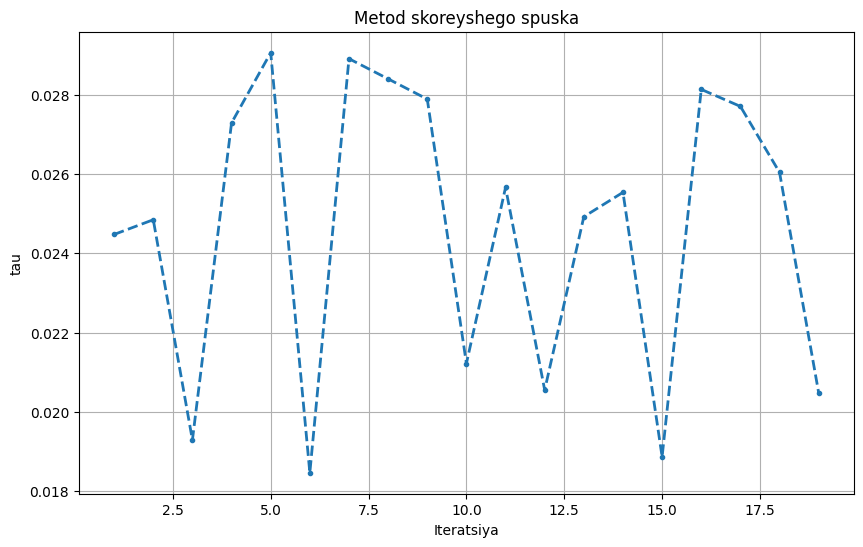


Pervye 10 znacheniya tau:
tau_1 = 2.45e-02
tau_2 = 2.48e-02
tau_3 = 1.93e-02
tau_4 = 2.73e-02
tau_5 = 2.91e-02
tau_6 = 1.85e-02
tau_7 = 2.89e-02
tau_8 = 2.84e-02
tau_9 = 2.79e-02
tau_10 = 2.12e-02


In [64]:
def spusk(A, b, maxi=1000, epsilon=1e-12):
    n = len(b)
    x = [0.0] * n
    t = []

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)
        if nevyazka < epsilon:
            break

        Ar = mv(A, r)
        chis = proizsvv(r, r)
        znam = proizsvv(r, Ar)

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x = summ(x, scalyar(tau, r))

        print(f"{k+1:8d}\t{tau:.2f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.2f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t

solution, tau_history = spusk(A, b, maxi=1000)


plt.figure(figsize=(10, 6))
plt.plot(range(1, len(tau_history)+1), tau_history, '.--', linewidth=2, markersize=6)
plt.xlabel('Iteratsiya')
plt.ylabel('tau')
plt.title('Metod skoreyshego spuska')
plt.grid(True)
plt.show()

print("\nPervye 10 znacheniya tau:")
for i, tau in enumerate(tau_history[:10], 1):
    print(f"tau_{i} = {tau:.2e}")

(array([0.92063264, 0.88185675, 0.8895586 , 0.83494962, 0.93075706]), 50)
       1	0.0244737254	0.0340853894	8.75e+01
       2	0.0261933531	0.2091862523	1.62e+01
       3	0.0197142544	0.2443283942	7.39e+00
       4	0.0176762626	0.7882739249	3.65e+00
       5	0.0155683866	1.1079126494	3.24e+00
       6	0.0089042352	0.8392919975	3.41e+00
       7	0.0061441557	0.8294983235	3.13e+00
       8	0.0051217154	0.9951394647	2.85e+00
       9	0.0044969525	1.1810803890	2.84e+00
      10	0.0038016773	1.2572152181	3.09e+00
      11	0.0030598565	1.2152468538	3.46e+00
      12	0.0024235444	1.1291401971	3.82e+00
      13	0.0019503997	1.0550377617	4.06e+00
      14	0.0016188337	1.0107009048	4.17e+00
      15	0.0013878424	0.9944773664	4.19e+00
      16	0.0012229392	0.9993057208	4.18e+00
      17	0.0011000608	1.0176929393	4.17e+00
      18	0.0010033235	1.0428556062	4.21e+00
      19	0.0009224797	1.0690121313	4.30e+00
      20	0.0008511633	1.0916861097	4.45e+00
      21	0.0007857340	1.1079917800	4.65e+00
  

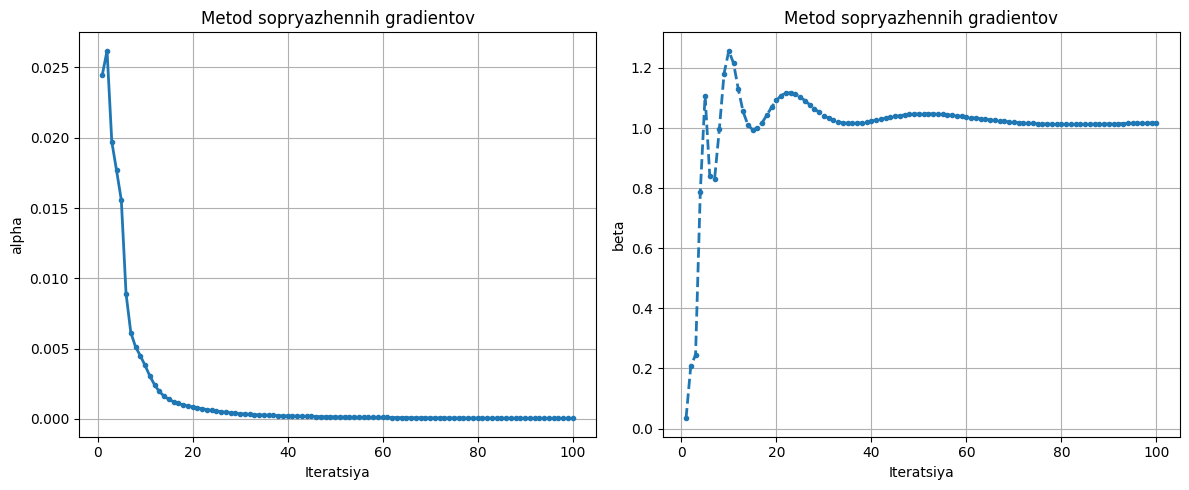


Pervye 10 znacheniy alpha i beta:
alpha_1 = 2.45e-02, beta_1 = 3.41e-02
alpha_2 = 2.62e-02, beta_2 = 2.09e-01
alpha_3 = 1.97e-02, beta_3 = 2.44e-01
alpha_4 = 1.77e-02, beta_4 = 7.88e-01
alpha_5 = 1.56e-02, beta_5 = 1.11e+00
alpha_6 = 8.90e-03, beta_6 = 8.39e-01
alpha_7 = 6.14e-03, beta_7 = 8.29e-01
alpha_8 = 5.12e-03, beta_8 = 9.95e-01
alpha_9 = 4.50e-03, beta_9 = 1.18e+00
alpha_10 = 3.80e-03, beta_10 = 1.26e+00


In [65]:
x = scipy.sparse.linalg.cg(np.asarray(A), np.asarray(b))
print(x)
def grad(A, b, maxi=1000, epsilon=1e-20):
    n = len(b)
    x = [0.0] * n
    aa = []
    bb = []

    r = razn(b, mv(A, x))
    p = r[:]

    for k in range(maxi):
        nevyazka = normv(r)

        if nevyazka < epsilon:
            break

        Ap = mv(A, p)
        chis_alpha = proizsvv(r, r)
        znam_alpha = proizsvv(Ap, p)
        alpha = chis_alpha / znam_alpha
        aa.append(alpha)
        
        x = summ(x, scalyar(alpha, p))

        r = razn(r, scalyar(alpha, Ap))

        chis_beta = proizsvv(r, r)
        znam_beta = chis_alpha

        if abs(znam_beta) < 1e-15:
            beta = 0.0
        else:
            beta = chis_beta / znam_beta

        bb.append(beta)
        p = summ(r, scalyar(beta, p))

        print(f"{k+1:8d}\t{alpha:.10f}\t{beta:.10f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(aa)}")

    return x, aa, bb

solution3, alpha3, beta3 = grad(A, b, maxi=100)


print(solution3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(range(1, len(alpha3)+1), alpha3, '.-', linewidth=2, markersize=6)
ax1.set_xlabel('Iteratsiya')
ax1.set_ylabel('alpha')
ax1.set_title('Metod sopryazhennih gradientov')
ax1.grid(True)

ax2.plot(range(1, len(beta3)+1), beta3, '.--', linewidth=2, markersize=6)
ax2.set_xlabel('Iteratsiya')
ax2.set_ylabel('beta')
ax2.set_title('Metod sopryazhennih gradientov')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nPervye 10 znacheniy alpha i beta:")
for i in range(min(10, len(alpha3))):
    print(f"alpha_{i+1} = {alpha3[i]:.2e}, beta_{i+1} = {beta3[i]:.2e}")

       1	0.0236670256	8.75e+01
       2	0.0210426701	1.59e+01
       3	0.0228529936	7.50e+00
       4	0.0255136575	1.49e+00
       5	0.0189180955	3.02e-01
       6	0.0267964109	1.51e-01
       7	0.0262742662	2.83e-02
       8	0.0254549379	6.16e-03
       9	0.0219301519	2.60e-03
      10	0.0253842765	4.92e-04
      11	0.0181859647	1.03e-04
      12	0.0277593481	5.00e-05
      13	0.0253215637	1.04e-05
      14	0.0278370939	2.54e-06
      15	0.0248806104	6.91e-07
      16	0.0266468409	1.47e-07
      17	0.0284564220	3.51e-08
      18	0.0189910110	9.44e-09
      19	0.0272036817	3.20e-09
Otvet: ['1.000000', '1.000000', '1.000000', '1.000000', '1.000000']
Norma: 7.72e-10
Pogreshnost: 2.12e-11
Iteratcii: 19


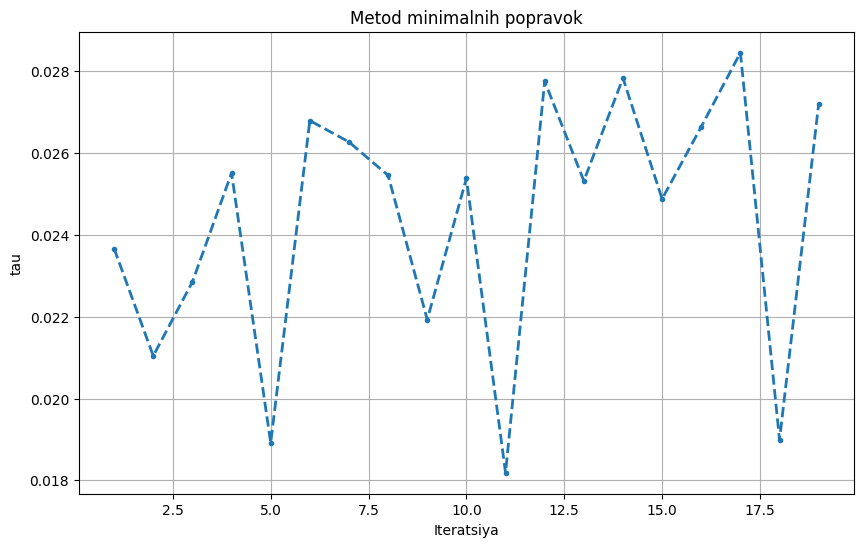


Pervye 10 znacheniy tau:
tau_1 = 2.37e-02
tau_2 = 2.10e-02
tau_3 = 2.29e-02
tau_4 = 2.55e-02
tau_5 = 1.89e-02
tau_6 = 2.68e-02
tau_7 = 2.63e-02
tau_8 = 2.55e-02
tau_9 = 2.19e-02
tau_10 = 2.54e-02


[np.float64(1.000000000007138),
 np.float64(0.9999999999935082),
 np.float64(0.9999999999979224),
 np.float64(0.9999999999814508),
 np.float64(1.0000000000024907)]

In [67]:

B= [
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
]


def minp(A,B, b, maxi=100, epsilon=1e-12):
    B_inv =  inv(B)
    n = len(b)
    x = [0.0] * n
    t = [] 

    for k in range(maxi):
        r = razn(b, mv(A, x))
        nevyazka = normv(r)

        if nevyazka < epsilon:
            break

        w = mv(B,  r)
        chis =proizsvv(mv(A, w),w)
        znam = proizsvv(mv(mm(B_inv,A), w), mv(A,w))

        if abs(znam) < 1e-15:
            break

        tau = chis/znam
        t.append(tau)
        x = summ(x, scalyar(tau, r))

        print(f"{k+1:8d}\t{tau:.10f}\t{nevyazka:.2e}")

    o = razn(b, mv(A, x))
    error = normv(razn(x, exact))

    print(f"Otvet: {[f'{val:.6f}' for val in x]}")
    print(f"Norma: {normv(o):.2e}")
    print(f"Pogreshnost: {error:.2e}")
    print(f"Iteratcii: {len(t)}")

    return x, t

solution2, tau2 = minp(A, B, b, maxi=100)

#график

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(tau2)+1), tau2, '.--', linewidth=2, markersize=6)
plt.xlabel('Iteratsiya')
plt.ylabel('tau')
plt.title('Metod minimalnih popravok')
plt.grid(True)
plt.show()

print("\nPervye 10 znacheniy tau:")
for i, tau in enumerate(tau2[:10], 1):
    print(f"tau_{i} = {tau:.2e}")
solution2

# Laba 8

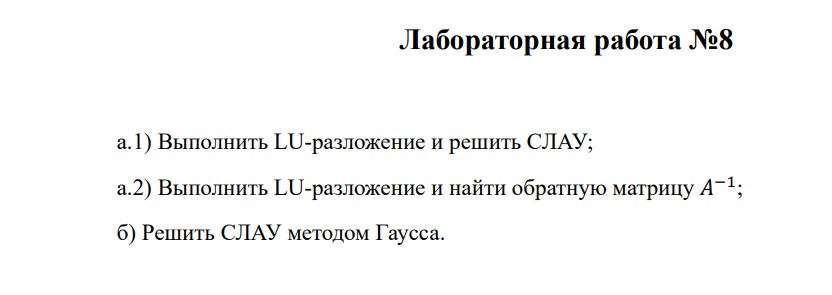

In [ ]:
# Лаба 8, вариант 7
# Без numpy/scipy: только списки и циклы.

def print_matrix(M, title=None, digits=6):
    if title:
        print(title)
    for row in M:
        print("  ".join(f"{v:.{digits}f}" for v in row))
    print()

def crout_lu(A):
    """
    LU-разложение :
    U имеет единицы на диагонали (u_ii = 1),
    L - нижняя треугольная с ненулевой диагональю.
    """
    n = len(A)
    L = [[0.0] * n for _ in range(n)]
    U = [[0.0] * n for _ in range(n)]
    for i in range(n):
        U[i][i] = 1.0

    for j in range(n):
        # 1) столбец L
        for i in range(j, n):
            s = 0.0
            for k in range(j):
                s += L[i][k] * U[k][j]
            L[i][j] = A[i][j] - s

        if abs(L[j][j]) < 1e-12:
            raise ZeroDivisionError("Нулевой ведущий элемент при LU-разложении.")

        # 2) строка U
        for k in range(j + 1, n):
            s = 0.0
            for m in range(j):
                s += L[j][m] * U[m][k]
            U[j][k] = (A[j][k] - s) / L[j][j]

    return L, U

def forward_substitution(L, b):
    """Решает Ly=b, где L - нижнетреугольная (диагональ НЕ обязана быть 1)."""
    n = len(L)
    y = [0.0] * n
    for i in range(n):
        s = 0.0
        for j in range(i):
            s += L[i][j] * y[j]
        y[i] = (b[i] - s) / L[i][i]
    return y

def back_substitution_unit_upper(U, y):
    """Решает Ux=y, где U - верхнетреугольная и u_ii = 1."""
    n = len(U)
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += U[i][j] * x[j]
        x[i] = y[i] - s
    return x

def solve_via_lu(A, b):
    L, U = crout_lu(A)
    y = forward_substitution(L, b)
    x = back_substitution_unit_upper(U, y)
    return x, L, U

def inverse_via_lu(A):
    """Находит A^{-1} через решение Ax = e_j для всех j (столбцы единичной матрицы)."""
    n = len(A)
    L, U = crout_lu(A)
    inv = [[0.0] * n for _ in range(n)]

    for j in range(n):
        e = [0.0] * n
        e[j] = 1.0
        y = forward_substitution(L, e)
        x = back_substitution_unit_upper(U, y)
        for i in range(n):
            inv[i][j] = x[i]
    return inv

def gauss_solve(A, b, pivot=True):
    """
    Метод Гаусса для Ax=b.
    pivot=True: выбор главного элемента по столбцу (частичный выбор),
    чтобы не делить на малые числа.
    """
    n = len(A)
    M = [A[i][:] + [b[i]] for i in range(n)]  # расширенная матрица

    # Прямой ход
    for k in range(n):
        if pivot:
            # найти строку с максимальным |M[i][k]|
            best = max(range(k, n), key=lambda i: abs(M[i][k]))
            M[k], M[best] = M[best], M[k]

        if abs(M[k][k]) < 1e-12:
            raise ZeroDivisionError("Нулевой ведущий элемент в методе Гаусса.")

        for i in range(k + 1, n):
            factor = M[i][k] / M[k][k]
            for j in range(k, n + 1):
                M[i][j] -= factor * M[k][j]

    # Обратный ход
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += M[i][j] * x[j]
        x[i] = (M[i][n] - s) / M[i][i]

    return x


def main():
    A = [
        [2, 10, -3, 6, -7],
        [3,  9, -4, 7, -8],
        [4, -8,  5, 6, -9],
        [5, -9, -6,-7, 10],
        [6, 10,  7, 8,-11],
    ]
    b = [4, 5, 4, 23, 34]
    x_star = [5, 1, 2, 3, 4]

    x, L, U = solve_via_lu(A, b)

    print("a.1) Решение Ax=b через LU")
    print("x =", [round(v, 12) for v in x])
    print("x*=", x_star)
    print()

    print_matrix(L, "Матрица L (Crout):", digits=6)
    print_matrix(U, "Матрица U (Crout, diag=1):", digits=6)

    # ---- Часть a.2) ----
    A_inv = inverse_via_lu(A)
    print_matrix(A_inv, "a.2) Обратная матрица A^{-1}:", digits=6)

    # ---- Часть б) ----
    A2 = [
        [2, -1, -1],
        [3,  4, -2],
        [3, -2,  4],
    ]
    b2 = [4, 11, 11]

    x2 = gauss_solve(A2, b2, pivot=True)
    print("б) Решение 3x3 методом Гаусса:")
    print("x =", [round(v, 12) for v in x2])


if __name__ == "__main__":
    main()


a.1) Решение Ax=b через LU
x = [5.0, 1.0, 2.0, 3.0, 4.0]
x*= [5, 1, 2, 3, 4]

Матрица L (Crout):
2.000000  0.000000  0.000000  0.000000  0.000000
3.000000  -6.000000  0.000000  0.000000  0.000000
4.000000  -28.000000  8.666667  0.000000  0.000000
5.000000  -34.000000  -1.333333  -10.153846  0.000000
6.000000  -20.000000  14.333333  -8.846154  1.969697

Матрица U (Crout, diag=1):
1.000000  5.000000  -1.500000  3.000000  -3.500000
0.000000  1.000000  -0.083333  0.333333  -0.416667
0.000000  0.000000  1.000000  0.384615  -0.769231
0.000000  0.000000  0.000000  1.000000  -1.212121
0.000000  0.000000  0.000000  0.000000  1.000000

a.2) Обратная матрица A^{-1}:
0.246154  -0.200000  0.034615  0.115385  0.065385
0.307692  -0.250000  -0.019231  0.019231  0.019231
-1.038462  0.750000  -0.153846  -0.096154  0.153846
-8.153846  6.750000  -1.115385  -0.634615  0.615385
-6.176923  5.050000  -0.907692  -0.442308  0.507692

б) Решение 3x3 методом Гаусса:
x = [3.0, 1.0, 1.0]


# Lab 10

In [33]:
def residual(a: list[float], b: list[float], c: list[float], d: list[float], x: list[float]) -> list[float]:
    """Вектор невязки r = A x - d для трёхдиагональной матрицы."""
    n = len(b)
    r = [0.0] * n
    for i in range(n):
        s = b[i] * x[i]
        if i > 0:
            s += a[i] * x[i - 1]
        if i < n - 1:
            s += c[i] * x[i + 1]
        r[i] = s - d[i]
    return r


def solve_right_sweep(a: list[float], b: list[float], c: list[float], d: list[float]) -> tuple[list[float], list[float], list[float]]:
    """
    Правая прогонка (Thomas): прямой ход даёт p,q, затем обратный ход даёт x.
    """
    n = len(b)
    p = [0.0] * n
    q = [0.0] * n

    # старт
    if b[0] == 0:
        raise ZeroDivisionError("b[0] = 0, нельзя начать прогонку")
    p[0] = -c[0] / b[0]
    q[0] = d[0] / b[0]

    # прямой ход
    for i in range(1, n):
        denom = b[i] + a[i] * p[i - 1]
        if denom == 0:
            raise ZeroDivisionError(f"На шаге i={i} denom=0, прогонка невозможна")
        p[i] = -c[i] / denom if i < n - 1 else 0.0
        q[i] = (d[i] - a[i] * q[i - 1]) / denom

    # обратный ход
    x = [0.0] * n
    x[n - 1] = q[n - 1]
    for i in range(n - 2, -1, -1):
        x[i] = p[i] * x[i + 1] + q[i]

    return x, p, q


def solve_left_sweep(a: list[float], b: list[float], c: list[float], d: list[float]) -> list[float]:
    """
    Левая прогонка: то же самое, но идём справа налево.
    Удобно реализовать как правую прогонку для "перевёрнутой" системы,
    затем перевернуть решение обратно.
    """
    n = len(b)
    a_r = [0.0] * n
    b_r = [0.0] * n
    c_r = [0.0] * n
    d_r = [0.0] * n

    # Перенумерация: y_i = x_{n-1-i}
    for i in range(n):
        j = n - 1 - i
        b_r[i] = b[j]
        d_r[i] = d[j]

        # В перевёрнутой системе:
        # нижняя диагональ = исходная верхняя (c),
        # верхняя диагональ = исходная нижняя (a)
        a_r[i] = 0.0 if i == 0 else c[j]
        c_r[i] = 0.0 if i == n - 1 else a[j]

    y, _, _ = solve_right_sweep(a_r, b_r, c_r, d_r)

    # Возвращаемся к x
    x = [0.0] * n
    for i in range(n):
        x[i] = y[n - 1 - i]
    return x


def solve_meeting_sweep(a: list[float], b: list[float], c: list[float], d: list[float], m: int) -> list[float]:
    """
    Встречная прогонка:
    - слева считаем p,q до узла m (включительно): x_m = p_m x_{m+1} + q_m
    - справа считаем A,B до узла m+1: x_{m+1} = A_{m+1} x_m + B_{m+1}
    - решаем систему 2x2 для x_m и x_{m+1}
    - достраиваем решение влево и вправо
    """
    n = len(b)
    if not (0 <= m < n - 1):
        raise ValueError("m должен быть в диапазоне 0..n-2")

    # 1) слева: x_i = p_i x_{i+1} + q_i
    p = [0.0] * n
    q = [0.0] * n
    p[0] = -c[0] / b[0]
    q[0] = d[0] / b[0]
    for i in range(1, m + 1):
        denom = b[i] + a[i] * p[i - 1]
        if denom == 0:
            raise ZeroDivisionError("denom=0 на прямом ходе (слева)")
        p[i] = -c[i] / denom
        q[i] = (d[i] - a[i] * q[i - 1]) / denom

    # 2) справа: x_i = A_i x_{i-1} + B_i
    A = [0.0] * n
    B = [0.0] * n
    A[n - 1] = -a[n - 1] / b[n - 1]
    B[n - 1] = d[n - 1] / b[n - 1]
    for i in range(n - 2, m, -1):
        denom = b[i] + c[i] * A[i + 1]
        if denom == 0:
            raise ZeroDivisionError("denom=0 на прямом ходе (справа)")
        A[i] = -a[i] / denom
        B[i] = (d[i] - c[i] * B[i + 1]) / denom

    # 3) “стык”: решаем 2 уравнения
    # x_m     = p_m x_{m+1} + q_m
    # x_{m+1} = A_{m+1} x_m + B_{m+1}
    pm, qm = p[m], q[m]
    Am1, Bm1 = A[m + 1], B[m + 1]

    denom = 1.0 - Am1 * pm
    if denom == 0:
        raise ZeroDivisionError("Нельзя состыковать (denom=0)")

    x_m1 = (Am1 * qm + Bm1) / denom
    x_m = pm * x_m1 + qm

    # 4) восстановление всего x
    x = [0.0] * n
    x[m] = x_m
    x[m + 1] = x_m1

    # влево
    for i in range(m - 1, -1, -1):
        x[i] = p[i] * x[i + 1] + q[i]

    # вправо
    for i in range(m + 2, n):
        x[i] = A[i] * x[i - 1] + B[i]

    return x


def main():
    # Вариант 7
    a = [0.0, 3.0, 1.0, 4.0, 1.0, -2.0]   # нижняя диагональ
    b = [2.0, 6.0, -5.0, -7.0, 5.0, 7.0]   # главная диагональ
    c = [-1.0, -2.0, 2.0, 1.0, 2.0, 0.0]   # верхняя диагональ
    d = [1.0, 9.0, 3.0, -6.0, 8.0, 5.0]    # правая часть

    x_right, p, q = solve_right_sweep(a, b, c, d)
    x_left = solve_left_sweep(a, b, c, d)

    # для n=6 удобно встречаться между x3 и x4 -> m=2 (0-индексация)
    x_meet = solve_meeting_sweep(a, b, c, d, m=2)

    print("Правая прогонка  x =", x_right)
    print("Левая прогонка   x =", x_left)
    print("Встречная прогонка x =", x_meet)

    # проверка невязки
    r = residual(a, b, c, d, x_right)
    print("Невязка (правая):", r)

    # сравнение с ответом из задания
    x_ref = [1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
    print("Совпадает с (1,1,0,1,1,1)?", all(abs(x_right[i] - x_ref[i]) < 1e-12 for i in range(6)))

    # если хотите, можно вывести коэффициенты прогонки p,q:
    print("p =", p)
    print("q =", q)


if __name__ == "__main__":
    main()


Правая прогонка  x = [1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
Левая прогонка   x = [1.0, 0.9999999999999999, -5.551115123125783e-17, 1.0, 1.0, 1.0]
Встречная прогонка x = [1.0, 1.0, 0.0, 1.0, 1.0, 1.0]
Невязка (правая): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Совпадает с (1,1,0,1,1,1)? True
p = [0.5, 0.26666666666666666, 0.4225352112676056, 0.1883289124668435, -0.38548057259713703, 0.0]
q = [0.5, 1.0, -0.4225352112676056, 0.8116710875331565, 1.385480572597137, 1.0]


# laba 9

In [ ]:
import math


# ---------- базовые операции (скалярное произведение, нормы, умножение) ----------

def dot(u, v):
    """(u, v) = sum(u_i v_i)""" 
    s = 0.0
    for ui, vi in zip(u, v):
        s += ui * vi
    return s


def norm2(u):
    """||u||_2 = sqrt((u, u))"""
    return math.sqrt(dot(u, u))


def normalize(u):
    """u / ||u||"""
    n = norm2(u)
    if n == 0.0:
        raise ValueError("Нельзя нормировать нулевой вектор")
    return [ui / n for ui in u]


def matvec(A, x):
    """y = A x"""
    n = len(A)
    y = [0.0] * n
    for i in range(n):
        s = 0.0
        for j in range(n):
            s += A[i][j] * x[j]
        y[i] = s
    return y


def argmax_abs(x):
    """индекс компоненты с максимальным |x_i|"""
    idx = 0
    best = abs(x[0])
    for i in range(1, len(x)):
        ai = abs(x[i])
        if ai > best:
            best = ai
            idx = i
    return idx


# ---------- метод 1: PM-разложение (степенной метод + отношение компонент) ----------

def max_eig_pm_decomposition(A, x0, eps=1e-12, max_iter=5000):
    """
    Итерации: y = A x, x = y / ||y||
    Оценка лямбда: y[p] / x_old[p], где p = argmax |x_old|
    """
    x = normalize(x0)
    lam_prev = None

    for k in range(1, max_iter + 1):
        y = matvec(A, x)

        p = argmax_abs(x)
        lam = y[p] / x[p]

        x = normalize(y)

        if lam_prev is not None and abs(lam - lam_prev) < eps:
            return lam, x, k

        lam_prev = lam

    return lam, x, max_iter


# ---------- метод 2: метод скалярных произведений (Релеевское отношение) ----------

def max_eig_scalar_products(A, x0, eps=1e-12, max_iter=5000):
    """
    lambda = (A x, x) / (x, x)
    затем x := (A x) / ||A x||
    """
    x = normalize(x0)
    lam_prev = None

    for k in range(1, max_iter + 1):
        y = matvec(A, x)  # y = A x

        lam = dot(y, x) / dot(x, x)  # (Ax, x)/(x, x)

        x = normalize(y)

        if lam_prev is not None and abs(lam - lam_prev) < eps:
            return lam, x, k

        lam_prev = lam

    return lam, x, max_iter


# ---------- данные варианта 7 и запуск ----------

def main():
    A = [
        [35,  3,  6,  0, -8],
        [ 3, 38,  6, -5,  0],
        [ 6,  6, 42, -4, -7],
        [ 0, -5, -4, 38,  4],
        [-8,  0, -7,  4, 48],
    ]

    # стартовый вектор (можно брать (1,1,1,1,1))
    x0 = [1, 1, 1, 1, 1]

    lam1, v1, it1 = max_eig_pm_decomposition(A, x0)
    lam2, v2, it2 = max_eig_scalar_products(A, x0)

    print("Метод PM-разложения:")
    print("  lambda_max ≈", lam1)
    print("  итераций:", it1)

    print("\nМетод скалярных произведений:")
    print("  lambda_max ≈", lam2)
    print("  итераций:", it2)

    # Для проверки через numpy (если преподаватель требует) — РАСКОММЕНТИРУЙТЕ:
    # import numpy as np
    # w = np.linalg.eigvals(np.array(A, dtype=float))
    # print("\nПроверка numpy: max eig =", max(w))


if __name__ == "__main__":
    main()


Метод PM-разложения:
  lambda_max ≈ 59.86444500556995
  итераций: 97

Метод скалярных произведений:
  lambda_max ≈ 59.86444500556646
  итераций: 53
